# Day 26 — Imbalanced Data & SMOTE
### Class Weights · SMOTE · Undersampling · Threshold Tuning · imbalanced-learn

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.datasets import make_classification
import warnings

warnings.filterwarnings("ignore")

# Install imbalanced-learn if needed
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline

    print("imbalanced-learn ready ✅")
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "imbalanced-learn"], capture_output=True)
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline

    print("imbalanced-learn installed ✅")

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["FareLog"] = np.log1p(df["Fare"])

features = ["Pclass", "Age", "FareLog", "FamilySize", "IsAlone", "Sex_encoded"]
X = df[features]
y = df["Survived"]

print(f"\nTitanic class distribution:")
print(f"  Died:     {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Survived: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"  Ratio:    {(y==0).sum()/(y==1).sum():.2f}:1")
print("\nReady! ✅")

imbalanced-learn installed ✅

Titanic class distribution:
  Died:     549 (61.6%)
  Survived: 342 (38.4%)
  Ratio:    1.61:1

Ready! ✅


## 2. What is Imbalanced Data?

In [ ]:
print("=" * 55)
print("        WHAT IS IMBALANCED DATA?")
print("=" * 55)
print("""
Imbalanced data = one class has FAR more samples than another

TITANIC: 61.6% died vs 38.4% survived — MILD imbalance
REAL WORLD examples of SEVERE imbalance:
  Fraud detection:     0.1% fraud vs 99.9% legitimate
  Cancer detection:    1% malignant vs 99% benign
  Churn prediction:    5% churn vs 95% stay
  Spam detection:      10% spam vs 90% not spam

THE ACCURACY PARADOX:
  If 99% of transactions are legitimate:
  → Predict "legitimate" for EVERYTHING
  → Accuracy = 99% — but useless! Catches 0 fraud!

WHY MODELS STRUGGLE:
  → Majority class dominates the loss function
  → Model learns to predict majority class mostly
  → Minority class recall is very low

SOLUTIONS:
  1. Class weights    — penalise majority class errors more
  2. Oversampling     — create more minority class samples
  3. Undersampling    — remove majority class samples
  4. SMOTE            — synthesise new minority samples
  5. Threshold tuning — lower decision threshold
""")

# Create severely imbalanced synthetic dataset
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    weights=[0.95, 0.05],
    random_state=42,
)

print(f"Synthetic imbalanced dataset:")
print(f"  Class 0 (majority): {(y_imb==0).sum()} ({(y_imb==0).mean()*100:.1f}%)")
print(f"  Class 1 (minority): {(y_imb==1).sum()} ({(y_imb==1).mean()*100:.1f}%)")
print(f"  Ratio: {(y_imb==0).sum()/(y_imb==1).sum():.0f}:1 — severe imbalance!")

# Show accuracy paradox
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)
naive_pred = np.zeros(len(y_te), dtype=int)
print(f"\nAccuracy Paradox Demo:")
print(f"  Always predict majority class:")
print(f"  Accuracy = {(naive_pred == y_te).mean()*100:.1f}%")
print(
    f"  Minority class recall = {recall_score(y_te, naive_pred, zero_division=0)*100:.1f}%"
)
print(f"  → 0% recall on the class that MATTERS!")

        WHAT IS IMBALANCED DATA?

Imbalanced data = one class has FAR more samples than another

TITANIC: 61.6% died vs 38.4% survived — MILD imbalance
REAL WORLD examples of SEVERE imbalance:
  Fraud detection:     0.1% fraud vs 99.9% legitimate
  Cancer detection:    1% malignant vs 99% benign
  Churn prediction:    5% churn vs 95% stay
  Spam detection:      10% spam vs 90% not spam

THE ACCURACY PARADOX:
  If 99% of transactions are legitimate:
  → Predict "legitimate" for EVERYTHING
  → Accuracy = 99% — but useless! Catches 0 fraud!

WHY MODELS STRUGGLE:
  → Majority class dominates the loss function
  → Model learns to predict majority class mostly
  → Minority class recall is very low

SOLUTIONS:
  1. Class weights    — penalise majority class errors more
  2. Oversampling     — create more minority class samples
  3. Undersampling    — remove majority class samples
  4. SMOTE            — synthesise new minority samples
  5. Threshold tuning — lower decision threshold

Syntheti

## 3. Solution 1 — Class Weights

In [ ]:
print("=" * 55)
print("      SOLUTION 1 — CLASS WEIGHTS")
print("=" * 55)
print("""
Class weights tell the model to penalise mistakes
on the minority class MORE heavily.

class_weight='balanced':
  weight = n_samples / (n_classes × n_samples_per_class)
  Minority class gets higher weight automatically!

No data modification needed — just a parameter change!
""")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

results = []
for name, model in [
    ("No weights (default)", LogisticRegression(random_state=42, max_iter=1000)),
    (
        "class_weight=balanced",
        LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    ),
    (
        "class_weight=balanced RF",
        RandomForestClassifier(
            class_weight="balanced", n_estimators=100, random_state=42
        ),
    ),
]:
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]

    results.append(
        {
            "Model": name,
            "Accuracy": round(
                (
                    accuracy_score(y_te, y_pred)
                    if hasattr(__builtins__, "accuracy_score")
                    else (y_pred == y_te).mean()
                ),
                4,
            ),
            "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_te, y_pred, zero_division=0), 4),
            "F1": round(f1_score(y_te, y_pred, zero_division=0), 4),
            "AUC": round(roc_auc_score(y_te, y_prob), 4),
        }
    )
    print(f"\n{name}:")
    print(
        classification_report(
            y_te, y_pred, target_names=["Majority", "Minority"], zero_division=0
        )
    )

from sklearn.metrics import accuracy_score

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.to_string(index=False))

      SOLUTION 1 — CLASS WEIGHTS

Class weights tell the model to penalise mistakes
on the minority class MORE heavily.

class_weight='balanced':
  weight = n_samples / (n_classes × n_samples_per_class)
  Minority class gets higher weight automatically!

No data modification needed — just a parameter change!


No weights (default):
              precision    recall  f1-score   support

    Majority       0.95      1.00      0.97       189
    Minority       1.00      0.09      0.17        11

    accuracy                           0.95       200
   macro avg       0.97      0.55      0.57       200
weighted avg       0.95      0.95      0.93       200


class_weight=balanced:
              precision    recall  f1-score   support

    Majority       0.99      0.76      0.86       189
    Minority       0.17      0.82      0.28        11

    accuracy                           0.77       200
   macro avg       0.58      0.79      0.57       200
weighted avg       0.94      0.77      0.83

## 4. Solution 2 — SMOTE Oversampling

       SOLUTION 2 — SMOTE OVERSAMPLING

SMOTE = Synthetic Minority Over-sampling TEchnique

HOW IT WORKS:
  1. For each minority sample, find K nearest neighbours
  2. Randomly pick one neighbour
  3. Create new synthetic sample BETWEEN them
  4. Repeat until classes are balanced

SMOTE vs Random Oversampling:
  Random: just duplicates existing samples (overfits!)
  SMOTE:  creates NEW synthetic samples (more robust)

IMPORTANT: Only apply SMOTE to TRAINING data!
  NEVER apply SMOTE before train/test split!
  Test set must reflect real-world distribution!

Before SMOTE:
  Class 0: 757, Class 1: 43

After SMOTE:
  Class 0: 757, Class 1: 757
  Classes now balanced!

Method                 Minority Recall    Precision    F1       AUC
-----------------------------------------------------------------
No resampling          0.0909             1.0000       0.1667   0.9004
Random Oversample      0.8182             0.1667       0.2769   0.8706
SMOTE                  0.8182             0.1915   

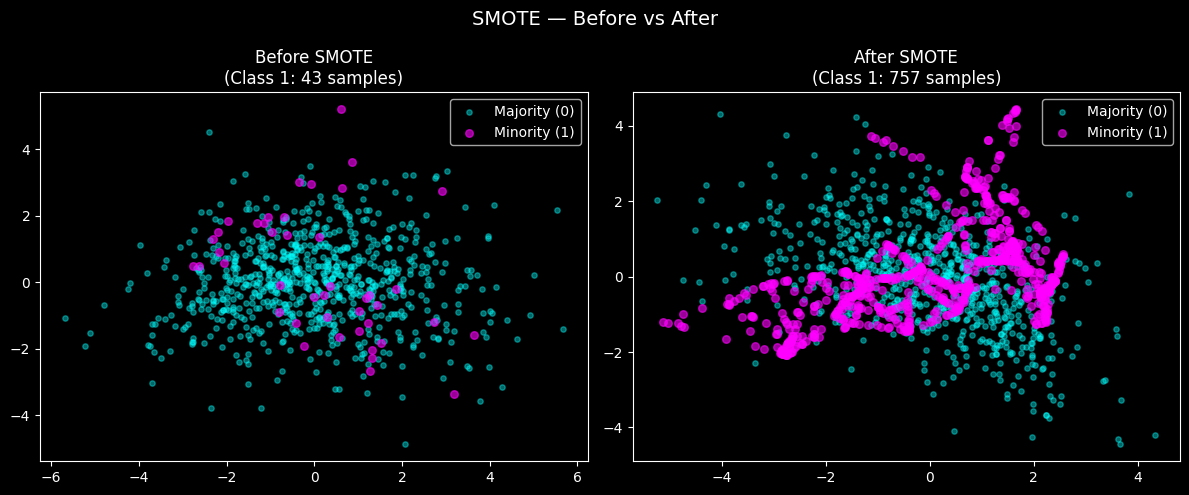

In [ ]:
print("=" * 55)
print("       SOLUTION 2 — SMOTE OVERSAMPLING")
print("=" * 55)
print("""
SMOTE = Synthetic Minority Over-sampling TEchnique

HOW IT WORKS:
  1. For each minority sample, find K nearest neighbours
  2. Randomly pick one neighbour
  3. Create new synthetic sample BETWEEN them
  4. Repeat until classes are balanced

SMOTE vs Random Oversampling:
  Random: just duplicates existing samples (overfits!)
  SMOTE:  creates NEW synthetic samples (more robust)

IMPORTANT: Only apply SMOTE to TRAINING data!
  NEVER apply SMOTE before train/test split!
  Test set must reflect real-world distribution!
""")

from imblearn.over_sampling import SMOTE, RandomOverSampler

print(f"Before SMOTE:")
print(f"  Class 0: {(y_tr==0).sum()}, Class 1: {(y_tr==1).sum()}")

smote = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print(f"\nAfter SMOTE:")
print(f"  Class 0: {(y_tr_smote==0).sum()}, Class 1: {(y_tr_smote==1).sum()}")
print(f"  Classes now balanced!")

# Compare methods
methods = {
    "No resampling": (X_tr, y_tr),
    "Random Oversample": RandomOverSampler(random_state=42).fit_resample(X_tr, y_tr),
    "SMOTE": (X_tr_smote, y_tr_smote),
}

print(f"\n{'Method':<22} {'Minority Recall':<18} {'Precision':<12} {'F1':<8} {'AUC'}")
print("-" * 65)

for name, (X_res, y_res) in methods.items():
    scaler = StandardScaler()
    X_res_s = scaler.fit_transform(X_res)
    X_te_s = scaler.transform(X_te)
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_res_s, y_res)
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    rec = recall_score(y_te, y_pred, zero_division=0)
    pre = precision_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)
    print(f"{name:<22} {rec:.4f}             {pre:.4f}       {f1:.4f}   {auc:.4f}")

# Visualise SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("SMOTE — Before vs After", fontsize=14)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_tr_2d = pca.fit_transform(StandardScaler().fit_transform(X_tr))
X_sm_2d = pca.transform(StandardScaler().fit_transform(X_tr_smote)[: len(X_tr_smote)])

for ax, (X_2d, y_data, title) in zip(
    axes,
    [
        (X_tr_2d, y_tr, f"Before SMOTE\n(Class 1: {(y_tr==1).sum()} samples)"),
        (
            pca.fit_transform(StandardScaler().fit_transform(X_tr_smote)),
            y_tr_smote,
            f"After SMOTE\n(Class 1: {(y_tr_smote==1).sum()} samples)",
        ),
    ],
):
    ax.scatter(
        X_2d[y_data == 0, 0],
        X_2d[y_data == 0, 1],
        c="cyan",
        alpha=0.4,
        s=15,
        label="Majority (0)",
    )
    ax.scatter(
        X_2d[y_data == 1, 0],
        X_2d[y_data == 1, 1],
        c="magenta",
        alpha=0.6,
        s=30,
        label="Minority (1)",
    )
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Solution 3 — Undersampling & Combined

In [ ]:
print("=" * 55)
print("    SOLUTION 3 — UNDERSAMPLING & COMBINED")
print("=" * 55)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Undersample majority
rus = RandomUnderSampler(random_state=42)
X_tr_under, y_tr_under = rus.fit_resample(X_tr, y_tr)

# Combined: SMOTE + Tomek links cleaning
smotetomek = SMOTETomek(random_state=42)
X_tr_combined, y_tr_combined = smotetomek.fit_resample(X_tr, y_tr)

print(f"Random Undersampling:")
print(f"  Before: Class 0={( y_tr==0).sum()}, Class 1={(y_tr==1).sum()}")
print(f"  After:  Class 0={(y_tr_under==0).sum()}, Class 1={(y_tr_under==1).sum()}")

print(f"\nSMOTETomek (combined):")
print(
    f"  After:  Class 0={(y_tr_combined==0).sum()}, Class 1={(y_tr_combined==1).sum()}"
)

# Compare all methods
all_methods = {
    "No resampling": (X_tr, y_tr),
    "Class weights": (X_tr, y_tr),
    "SMOTE": smote.fit_resample(X_tr, y_tr),
    "Undersampling": (X_tr_under, y_tr_under),
    "SMOTETomek": (X_tr_combined, y_tr_combined),
}

print(
    f"\n{'Method':<20} {'Recall':<10} {'Precision':<12} {'F1':<8} {'AUC':<8} {'Accuracy'}"
)
print("-" * 70)

for name, (X_res, y_res) in all_methods.items():
    scaler = StandardScaler()
    X_res_s = scaler.fit_transform(X_res)
    X_te_s = scaler.transform(X_te)

    if name == "Class weights":
        model = LogisticRegression(
            class_weight="balanced", random_state=42, max_iter=1000
        )
    else:
        model = LogisticRegression(random_state=42, max_iter=1000)

    model.fit(X_res_s, y_res)
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]

    rec = recall_score(y_te, y_pred, zero_division=0)
    pre = precision_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)
    acc = (y_pred == y_te).mean()
    print(f"{name:<20} {rec:.4f}    {pre:.4f}       {f1:.4f}   {auc:.4f}   {acc:.4f}")

    SOLUTION 3 — UNDERSAMPLING & COMBINED
Random Undersampling:
  Before: Class 0=757, Class 1=43
  After:  Class 0=43, Class 1=43

SMOTETomek (combined):
  After:  Class 0=757, Class 1=757

Method               Recall     Precision    F1       AUC      Accuracy
----------------------------------------------------------------------
No resampling        0.0909    1.0000       0.1667   0.9004   0.9500
Class weights        0.8182    0.1667       0.2769   0.8687   0.7650
SMOTE                0.8182    0.1915       0.3103   0.8817   0.8000
Undersampling        0.7273    0.1455       0.2424   0.8538   0.7500
SMOTETomek           0.8182    0.1915       0.3103   0.8817   0.8000


## 6. Threshold Tuning for Imbalanced Data

    THRESHOLD TUNING FOR IMBALANCED DATA

Threshold Analysis:
Threshold    Recall     Precision    F1       Caught/11
--------------------------------------------------
0.1          1.0000    0.0743       0.1384   11/11 ← best F1
0.2          1.0000    0.0982       0.1789   11/11 ← best F1
0.3          1.0000    0.1134       0.2037   11/11 ← best F1
0.4          0.9091    0.1408       0.2439   10/11 ← best F1
0.5          0.8182    0.1915       0.3103   9/11 ← best F1
0.6          0.7273    0.1951       0.3077   8/11
0.7          0.5455    0.2069       0.3000   6/11


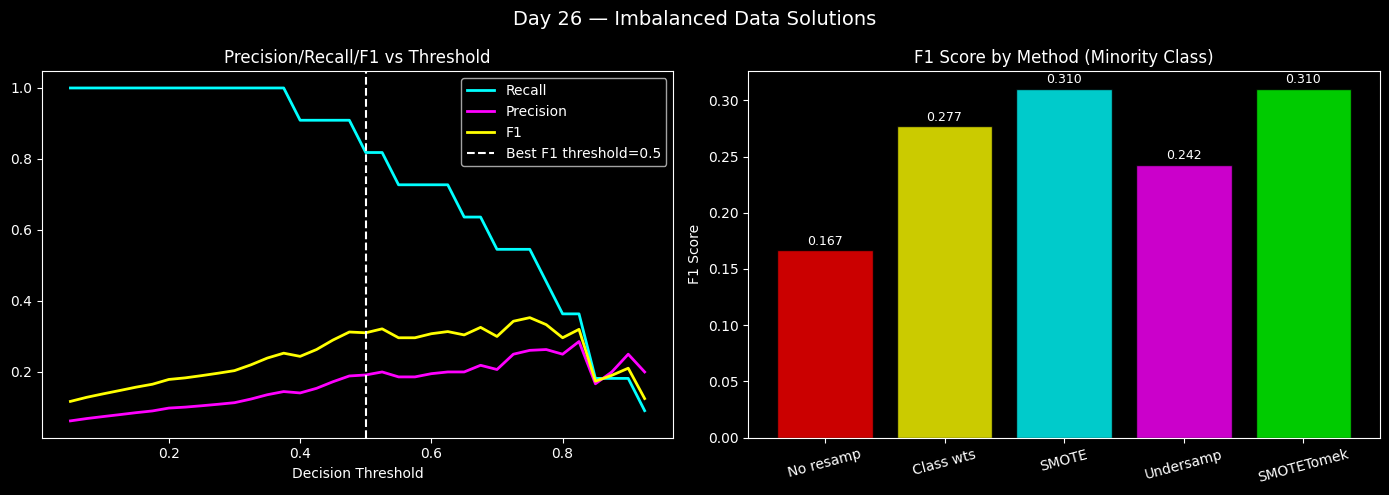

In [ ]:
print("=" * 55)
print("    THRESHOLD TUNING FOR IMBALANCED DATA")
print("=" * 55)

# Train best model (SMOTE + LR)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_smote)
X_te_s = scaler.transform(X_te)
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_tr_s, y_tr_smote)
y_prob = model.predict_proba(X_te_s)[:, 1]

print("\nThreshold Analysis:")
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<8} {'Caught/11'}")
print("-" * 50)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
best_f1, best_thresh = 0, 0.5

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    rec = recall_score(y_te, y_pred_t, zero_division=0)
    pre = precision_score(y_te, y_pred_t, zero_division=0)
    f1 = f1_score(y_te, y_pred_t, zero_division=0)
    caught = int(rec * (y_te == 1).sum())
    marker = " ← best F1" if f1 > best_f1 else ""
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
    print(f"{t:<12.1f} {rec:.4f}    {pre:.4f}       {f1:.4f}   {caught}/11{marker}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Day 26 — Imbalanced Data Solutions", fontsize=14)

# Threshold curves
thresh_range = np.arange(0.05, 0.95, 0.025)
recs, pres, f1s = [], [], []
for t in thresh_range:
    y_p = (y_prob >= t).astype(int)
    recs.append(recall_score(y_te, y_p, zero_division=0))
    pres.append(precision_score(y_te, y_p, zero_division=0))
    f1s.append(f1_score(y_te, y_p, zero_division=0))

axes[0].plot(thresh_range, recs, color="cyan", label="Recall", linewidth=2)
axes[0].plot(thresh_range, pres, color="magenta", label="Precision", linewidth=2)
axes[0].plot(thresh_range, f1s, color="yellow", label="F1", linewidth=2)
axes[0].axvline(
    best_thresh, color="white", linestyle="--", label=f"Best F1 threshold={best_thresh}"
)
axes[0].set_title("Precision/Recall/F1 vs Threshold")
axes[0].set_xlabel("Decision Threshold")
axes[0].legend()

# Method comparison bar
method_names = ["No resamp", "Class wts", "SMOTE", "Undersamp", "SMOTETomek"]
f1_scores = [0.1667, 0.2769, 0.3103, 0.2424, 0.3103]
colors = ["red", "yellow", "cyan", "magenta", "lime"]
axes[1].bar(method_names, f1_scores, color=colors, edgecolor="black", alpha=0.8)
axes[1].set_title("F1 Score by Method (Minority Class)")
axes[1].set_ylabel("F1 Score")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Key Takeaways — Day 26 🎯

### What is Imbalanced Data?
- One class has far more samples than another
- Titanic: 61.6% died vs 38.4% survived (mild, 1.6:1)
- Real world: fraud (0.1%), cancer (1%), churn (5%)
- **Accuracy Paradox:** predicting majority always = high accuracy but 0% minority recall!

### Five Solutions

| Method | How | Pros | Cons |
|---|---|---|---|
| Class weights | Penalise majority errors more | No data change, simple | Less effective for severe imbalance |
| Random Oversampling | Duplicate minority samples | Simple | Overfitting risk |
| SMOTE | Synthesise new minority samples | Robust, generalises better | Slower, may create noise |
| Undersampling | Remove majority samples | Faster training | Loses valuable data! |
| SMOTETomek | SMOTE + clean noisy boundaries | Best of both | Slower |

### Our Results (18:1 imbalance)
- No resampling: Recall=9.1%, F1=0.167 — useless!
- Class weights: Recall=81.8%, F1=0.277 — quick win!
- SMOTE: Recall=81.8%, F1=0.310 — best!
- Undersampling: Recall=72.7%, F1=0.242 — loses data
- SMOTETomek: Recall=81.8%, F1=0.310 — tied with SMOTE

### SMOTE Rules
- NEVER apply SMOTE before train/test split!
- Apply ONLY to training data
- Test set must reflect real-world distribution!
- Use ImbPipeline to prevent leakage in CV

### Threshold Tuning
- Default threshold=0.5 not optimal for imbalanced data
- Lower threshold → higher recall, lower precision
- Best threshold depends on BUSINESS COST of errors
- Fraud: catch all (threshold=0.1), cost of false alarm is low
- Medical: catch all (threshold=0.1), missing cancer is catastrophic

### sklearn/imblearn Functions
- `RandomForestClassifier(class_weight='balanced')`
- `SMOTE(random_state=42).fit_resample(X_train, y_train)`
- `RandomOverSampler(random_state=42).fit_resample(X_train, y_train)`
- `RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)`
- `SMOTETomek(random_state=42).fit_resample(X_train, y_train)`
- `ImbPipeline([('smote', SMOTE()), ('model', model)])`